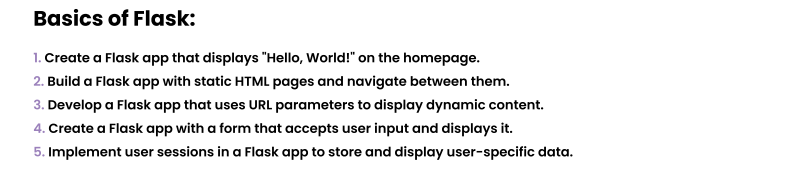

In [ ]:
#1
from flask import Flask

app = Flask(__name__)

@app.route('/')
def hello_world():
    return "Hello, World!"

if __name__ == '__main__':
    app.run(debug=True)


This code creates a simple Flask app with one route (/) that returns the string "Hello, World!" when accessed. The app runs on the local server with debugging enabled.

In [ ]:
#2
from flask import Flask, render_template

app = Flask(__name__)

@app.route('/')
def home():
    return render_template('home.html')

@app.route('/about')
def about():
    return render_template('about.html')

if __name__ == '__main__':
    app.run(debug=True)


Directory Structure:

In [ ]:
/project
    /templates
        home.html
        about.html
    app.py


home.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Home</title>
</head>
<body>
    <h1>Home Page</h1>
    <a href="/about">Go to About</a>
</body>
</html>


about.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>About</title>
</head>
<body>
    <h1>About Page</h1>
    <a href="/">Go to Home</a>
</body>
</html>


This Flask app has two routes: / for the home page and /about for the about page. It uses the render_template function to render HTML pages stored in the templates directory. Navigation between pages is provided by hyperlinks.

In [ ]:
#3
from flask import Flask

app = Flask(__name__)

@app.route('/greet/<name>')
def greet(name):
    return f"Hello, {name}!"

if __name__ == '__main__':
    app.run(debug=True)


This Flask app defines a route /greet/<name>, where <name> is a URL parameter. The app greets the user by name, with the name provided in the URL. For example, accessing /greet/John would display "Hello, John!".

In [ ]:
#4
from flask import Flask, request, render_template

app = Flask(__name__)

@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':
        name = request.form.get('name')
        return f"Hello, {name}!"
    return render_template('form.html')

if __name__ == '__main__':
    app.run(debug=True)


form.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Form</title>
</head>
<body>
    <form method="post">
        <label for="name">Enter your name:</label>
        <input type="text" id="name" name="name">
        <input type="submit" value="Submit">
    </form>
</body>
</html>


This app has a route (/) that handles both GET and POST requests. When the form is submitted, the app retrieves the user's input from the form and displays a greeting. The form is defined in form.html.

In [ ]:
#5
from flask import Flask, session, redirect, url_for, request, render_template

app = Flask(__name__)
app.secret_key = 'supersecretkey'

@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':
        session['username'] = request.form['username']
        return redirect(url_for('welcome'))
    return render_template('login.html')

@app.route('/welcome')
def welcome():
    if 'username' in session:
        return f"Welcome, {session['username']}!"
    return redirect(url_for('index'))

@app.route('/logout')
def logout():
    session.pop('username', None)
    return redirect(url_for('index'))

if __name__ == '__main__':
    app.run(debug=True)


login.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Login</title>
</head>
<body>
    <form method="post">
        <label for="username">Enter your username:</label>
        <input type="text" id="username" name="username">
        <input type="submit" value="Login">
    </form>
</body>
</html>


This app uses Flask sessions to store user-specific data (username). When the user logs in by submitting their username, it is stored in the session. The app then greets the user by name on the welcome page. Users can log out, which clears the session data.

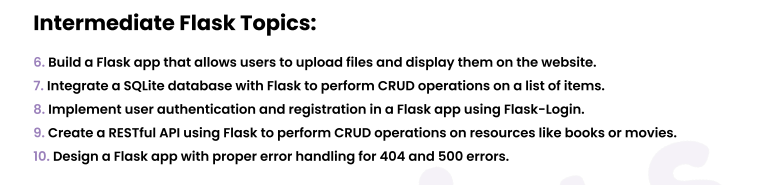

In [ ]:
#6
from flask import Flask, render_template, request, redirect, url_for
import os

app = Flask(__name__)
app.config['UPLOAD_FOLDER'] = 'uploads/'

if not os.path.exists(app.config['UPLOAD_FOLDER']):
    os.makedirs(app.config['UPLOAD_FOLDER'])

@app.route('/', methods=['GET', 'POST'])
def upload_file():
    if request.method == 'POST':
        file = request.files['file']
        if file:
            file_path = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
            file.save(file_path)
            return redirect(url_for('uploaded_file', filename=file.filename))
    return render_template('upload.html')

@app.route('/uploads/<filename>')
def uploaded_file(filename):
    return f'File uploaded successfully! Filename: {filename}'

if __name__ == '__main__':
    app.run(debug=True)


upload.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>File Upload</title>
</head>
<body>
    <h1>Upload a File</h1>
    <form method="post" enctype="multipart/form-data">
        <input type="file" name="file">
        <input type="submit" value="Upload">
    </form>
</body>
</html>


This app allows users to upload files via a web form. The uploaded file is saved in a directory specified by UPLOAD_FOLDER, and the app redirects the user to a page showing the file name.

In [ ]:
#7
from flask import Flask, render_template, request, redirect, url_for
import sqlite3

app = Flask(__name__)
DATABASE = 'items.db'

def get_db():
    conn = sqlite3.connect(DATABASE)
    return conn

@app.route('/')
def index():
    conn = get_db()
    cur = conn.cursor()
    cur.execute("SELECT * FROM items")
    items = cur.fetchall()
    conn.close()
    return render_template('index.html', items=items)

@app.route('/add', methods=['POST'])
def add_item():
    conn = get_db()
    cur = conn.cursor()
    cur.execute("INSERT INTO items (name) VALUES (?)", (request.form['name'],))
    conn.commit()
    conn.close()
    return redirect(url_for('index'))

@app.route('/delete/<int:id>')
def delete_item(id):
    conn = get_db()
    cur = conn.cursor()
    cur.execute("DELETE FROM items WHERE id = ?", (id,))
    conn.commit()
    conn.close()
    return redirect(url_for('index'))

if __name__ == '__main__':
    conn = get_db()
    cur = conn.cursor()
    cur.execute('''CREATE TABLE IF NOT EXISTS items
                   (id INTEGER PRIMARY KEY AUTOINCREMENT, name TEXT)''')
    conn.commit()
    conn.close()
    app.run(debug=True)


index.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Item List</title>
</head>
<body>
    <h1>Items</h1>
    <form action="/add" method="post">
        <input type="text" name="name">
        <input type="submit" value="Add">
    </form>
    <ul>
        {% for item in items %}
            <li>{{ item[1] }} <a href="/delete/{{ item[0] }}">Delete</a></li>
        {% endfor %}
    </ul>
</body>
</html>


This Flask app integrates with a SQLite database to perform CRUD (Create, Read, Update, Delete) operations on a list of items. Users can add items through a form, view the list, and delete items.

In [ ]:
#8
from flask import Flask, render_template, redirect, url_for, request
from flask_login import LoginManager, UserMixin, login_user, logout_user, login_required, current_user

app = Flask(__name__)
app.secret_key = 'supersecretkey'
login_manager = LoginManager()
login_manager.init_app(app)

users = {'testuser': {'password': 'testpassword'}}

class User(UserMixin):
    def __init__(self, username):
        self.id = username

@login_manager.user_loader
def load_user(username):
    return User(username) if username in users else None

@app.route('/')
def home():
    return 'Home Page. <a href="/login">Login</a> | <a href="/logout">Logout</a>'

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        username = request.form['username']
        password = request.form['password']
        if username in users and users[username]['password'] == password:
            user = User(username)
            login_user(user)
            return redirect(url_for('dashboard'))
    return render_template('login.html')

@app.route('/dashboard')
@login_required
def dashboard():
    return f'Welcome, {current_user.id}! <a href="/logout">Logout</a>'

@app.route('/logout')
@login_required
def logout():
    logout_user()
    return redirect(url_for('home'))

if __name__ == '__main__':
    app.run(debug=True)


login.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Login</title>
</head>
<body>
    <h1>Login</h1>
    <form method="post">
        <input type="text" name="username" placeholder="Username">
        <input type="password" name="password" placeholder="Password">
        <input type="submit" value="Login">
    </form>
</body>
</html>


This app uses Flask-Login for user authentication. Users can log in, access a dashboard, and log out. The app uses an in-memory dictionary to store users for simplicity.

In [ ]:
#9
from flask import Flask, jsonify, request

app = Flask(__name__)

books = [
    {'id': 1, 'title': '1984', 'author': 'George Orwell'},
    {'id': 2, 'title': 'To Kill a Mockingbird', 'author': 'Harper Lee'}
]

@app.route('/books', methods=['GET'])
def get_books():
    return jsonify(books)

@app.route('/books/<int:id>', methods=['GET'])
def get_book(id):
    book = next((book for book in books if book['id'] == id), None)
    return jsonify(book)

@app.route('/books', methods=['POST'])
def create_book():
    new_book = request.get_json()
    books.append(new_book)
    return jsonify(new_book), 201

@app.route('/books/<int:id>', methods=['PUT'])
def update_book(id):
    book = next((book for book in books if book['id'] == id), None)
    if book:
        data = request.get_json()
        book.update(data)
        return jsonify(book)
    return jsonify({'error': 'Book not found'}), 404

@app.route('/books/<int:id>', methods=['DELETE'])
def delete_book(id):
    global books
    books = [book for book in books if book['id'] != id]
    return jsonify({'message': 'Book deleted'})

if __name__ == '__main__':
    app.run(debug=True)


This Flask app provides a RESTful API for managing books. It supports all CRUD operations: listing all books, retrieving a specific book by ID, creating a new book, updating an existing book, and deleting a book.

In [ ]:
#10
from flask import Flask, render_template

app = Flask(__name__)

@app.route('/')
def home():
    return 'Home Page'

@app.errorhandler(404)
def page_not_found(e):
    return render_template('404.html'), 404

@app.errorhandler(500)
def internal_server_error(e):
    return render_template('500.html'), 500

if __name__ == '__main__':
    app.run(debug=True)


404.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>404 Not Found</title>
</head>
<body>
    <h1>404 - Page Not Found</h1>
    <p>The page you are looking for does not exist.</p>
    <a href="/">Go to Home</a>
</body>
</html>


500.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>500 Internal Server Error</title>
</head>
<body>
    <h1>500 - Internal Server Error</h1>
    <p>Something went wrong on our end.</p>
    <a href="/">Go to Home</a>
</body>
</html>


This Flask app handles 404 (Page Not Found) and 500 (Internal Server Error) errors by rendering custom HTML pages. This provides users with a more friendly error message and navigation options.

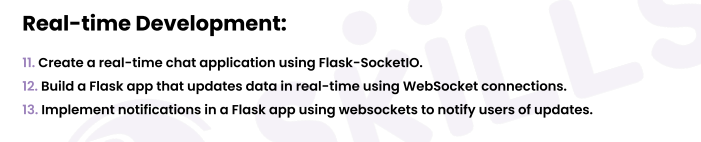

In [ ]:
#11
from flask import Flask, render_template
from flask_socketio import SocketIO, send

app = Flask(__name__)
app.config['SECRET_KEY'] = 'secret!'
socketio = SocketIO(app)

@app.route('/')
def index():
    return render_template('chat.html')

@socketio.on('message')
def handle_message(msg):
    print(f"Message: {msg}")
    send(msg, broadcast=True)

if __name__ == '__main__':
    socketio.run(app, debug=True)


chat.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Chat</title>
</head>
<body>
    <h1>Real-Time Chat</h1>
    <ul id="messages"></ul>
    <input id="message_input" autocomplete="off" placeholder="Type your message...">
    <button onclick="sendMessage()">Send</button>

    <script src="https://cdn.socket.io/4.0.0/socket.io.min.js"></script>
    <script type="text/javascript">
        const socket = io();

        socket.on('message', function(msg){
            const item = document.createElement('li');
            item.textContent = msg;
            document.getElementById('messages').appendChild(item);
        });

        function sendMessage() {
            const input = document.getElementById('message_input');
            const message = input.value;
            socket.send(message);
            input.value = '';
        }
    </script>
</body>
</html>


This example sets up a real-time chat application using Flask-SocketIO. Users can send messages that are broadcast to all connected clients in real-time.

In [ ]:
#12
from flask import Flask, render_template
from flask_socketio import SocketIO, emit
import random
import time

app = Flask(__name__)
app.config['SECRET_KEY'] = 'secret!'
socketio = SocketIO(app)

@app.route('/')
def index():
    return render_template('data.html')

def generate_data():
    while True:
        data = {'value': random.randint(1, 100)}
        socketio.emit('updateData', data)
        time.sleep(2)

@socketio.on('connect')
def handle_connect():
    socketio.start_background_task(generate_data)

if __name__ == '__main__':
    socketio.run(app, debug=True)


data.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Real-Time Data</title>
</head>
<body>
    <h1>Real-Time Data Updates</h1>
    <div id="data_value">Waiting for data...</div>

    <script src="https://cdn.socket.io/4.0.0/socket.io.min.js"></script>
    <script type="text/javascript">
        const socket = io();

        socket.on('updateData', function(data){
            document.getElementById('data_value').textContent = "Data Value: " + data.value;
        });
    </script>
</body>
</html>


This Flask app uses WebSocket connections to update data on the client-side in real-time. The generate_data function simulates a data stream that sends random values to all connected clients every 2 seconds.

In [ ]:
#13
from flask import Flask, render_template
from flask_socketio import SocketIO, emit

app = Flask(__name__)
app.config['SECRET_KEY'] = 'secret!'
socketio = SocketIO(app)

@app.route('/')
def index():
    return render_template('notifications.html')

@app.route('/trigger_notification')
def trigger_notification():
    message = "New notification!"
    socketio.emit('notify', {'message': message})
    return "Notification sent!"

if __name__ == '__main__':
    socketio.run(app, debug=True)


notifications.html:

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Notifications</title>
</head>
<body>
    <h1>Real-Time Notifications</h1>
    <div id="notifications"></div>

    <script src="https://cdn.socket.io/4.0.0/socket.io.min.js"></script>
    <script type="text/javascript">
        const socket = io();

        socket.on('notify', function(data){
            const notification = document.createElement('div');
            notification.textContent = data.message;
            document.getElementById('notifications').appendChild(notification);
        });
    </script>
</body>
</html>


This Flask app allows you to trigger notifications that are sent to all connected users in real-time via WebSockets. When the /trigger_notification route is accessed, a notification is sent to all users and displayed on their screens.